In [52]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.signal import butter, filtfilt
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import r2_score, mean_squared_error

### Convert .txt files to .csv

In [56]:
# Set your directory path here - Commented out to prevent re-running
folder = r"C:\Users\lmicklem\Documents\GitHub\Muscle_Sensory\Muscle_length_sensory\18-03-2026 Length Characterisation\18-03-2026 Length Characterisation"

for s in range(1, 31):       # S001 to S031
    for p in range(1, 6):    # P001 to P005
        
        filename = f"S{s:03d}P{p:03d}.txt"
        input_path = os.path.join(folder, filename)
        
        if not os.path.exists(input_path):
            print(f"Missing: {filename}")
            continue
        
        # print(f"Processing: {filename}")
        
        # Read comma-separated txt
        df = pd.read_csv(input_path)
        
        # Force first two columns to 3-digit zero-padded format
        for col in df.columns[:2]:
            df[col] = df[col].astype(int).astype(str).str.zfill(3)

        # Rename third column to 't (ms)'
        cols = list(df.columns)
        cols[2] = 't (ms)'
        df.columns = cols
        
        # Save as CSV (same folder)
        output_filename = filename.replace('.txt', '.csv')
        output_path = os.path.join(folder, output_filename)
        
        df.to_csv(output_path, index=False)

### Tare time 

In [58]:
for s in range(1, 31):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            print(f"Missing: {filename}")
            continue
        
        # print(f"Processing: {filename}")
        
        df = pd.read_csv(file_path)
        
        # Ensure 't (s)' is numeric
        time_col = pd.to_numeric(df['t (ms)'], errors='coerce')
        
        # Get first value (equivalent to C2)
        t0 = time_col.iloc[0]
        
        # Create relative time column
        df['t_rel(s)'] = (time_col - t0)/1000
        
        # Save back to same file
        df.to_csv(file_path, index=False)

In [6]:
def butter_lowpass_filter(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

### Calculate Velocity, Strain, Strain rate, Filter Voltage, dV/dt

In [60]:
L0 = 0.155  # initial length in meters

# SavGol parameters (tune if needed)
WINDOW = 21   # must be odd
POLY   = 3

for s in range(1, 31):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            print(f"Missing: {filename}")
            continue
        
        # print(f"Processing: {filename}")
        
        df = pd.read_csv(file_path)
        
        # Clean column names (removes accidental spaces)
        df.columns = df.columns.str.strip()
        
        # --- Ensure numeric ---
        disp = pd.to_numeric(df['Displacement (mm)'], errors='coerce')
        time = pd.to_numeric(df['t_rel(s)'], errors='coerce')
        lw_raw   = pd.to_numeric(df['LW (V)'], errors='coerce')  # 

        # --- Strain ---
        strain = disp / (1000 * L0)

        # --- Sampling frequency ---
        dt_mean = np.mean(np.diff(time))
        fs = 1 / dt_mean if dt_mean > 0 else 1
        
        # --- Butterworth filter ---
        cutoff = 2  # Hz (tune this)
        disp_filtered = butter_lowpass_filter(disp, cutoff, fs)
        
        # Replace displacement with filtered version for calculations
        disp = pd.Series(disp_filtered)

        # --- Rename raw LW column ---
        df.rename(columns={'LW (V)': 'LW raw(V)'}, inplace=True)

        # --- SavGol filter ---
        # Ensure window is valid
        window = min(WINDOW, len(lw_raw) if len(lw_raw)%2==1 else len(lw_raw)-1)
        if window < 3:
            lw_filt = lw_raw.copy()
        else:
            lw_filt = savgol_filter(lw_raw, window_length=window, polyorder=POLY)
        
        df['LW (V)'] = lw_filt  # filtered signal        
        
        # --- Central differences ---
        delta_d = disp.shift(-1) - disp.shift(1)      # mm
        delta_t = time.shift(-1) - time.shift(1)      # s
        
        # Convert displacement to meters
        delta_d_m = delta_d / 1000
        
        # Velocity
        vel = delta_d_m / delta_t
        
        # Handle edges (first and last rows)
        delta_d_m.iloc[0] = 0
        delta_d_m.iloc[-1] = 0
        delta_t.iloc[0] = 0
        delta_t.iloc[-1] = 0
        vel.iloc[0] = 0
        vel.iloc[-1] = 0
        
        # Clean NaN / inf
        vel = vel.replace([float('inf'), -float('inf')], 0).fillna(0)
        delta_d_m = delta_d_m.fillna(0)
        delta_t = delta_t.fillna(0)
        
        # --- Central difference for strain rate ---
        dstrain = strain.shift(-1) - strain.shift(1)
        dt = time.shift(-1) - time.shift(1)
        
        strain_rate = dstrain / dt
        
        # Handle edges
        strain.iloc[0] = 0
        strain_rate.iloc[0] = 0
        strain_rate.iloc[-1] = 0
        
        # Clean NaN / inf
        strain = strain.fillna(0)
        strain_rate = strain_rate.replace([float('inf'), -float('inf')], 0).fillna(0)

         # --- dv/dt RAW ---
        dv_raw = lw_raw.shift(-1) - lw_raw.shift(1)
        dt_v = time.shift(-1) - time.shift(1)
        
        dvdt_raw = dv_raw / dt_v
        dvdt_raw.iloc[[0, -1]] = 0
        dvdt_raw = dvdt_raw.replace([float('inf'), -float('inf')], 0).fillna(0)

        # --- dv/dt FILTERED ---
        lw_series = pd.Series(lw_filt)
        dv = lw_series.shift(-1) - lw_series.shift(1)
        
        dvdt = dv / dt_v
        dvdt.iloc[[0, -1]] = 0
        dvdt = dvdt.replace([float('inf'), -float('inf')], 0).fillna(0)

        # --- Add columns ---
        df['delta d (m)'] = delta_d_m
        df['delta t (s)'] = delta_t
        df['vel (m/s)'] = vel
        df['strain'] = strain
        df['strain rate (1/s)'] = strain_rate
        
        df['dv/dt raw'] = dvdt_raw
        df['dv/dt'] = dvdt
        
        # Save back
        df.to_csv(file_path, index=False)

### Read and Plot Data functions

In [62]:
def load_and_average(S_value, folder_path):
    data_list = []
    
    for p in range(1, 6):
        P_value = f"{p:03d}"
        filename = f"S{S_value}P{P_value}.csv"
        filepath = os.path.join(folder_path, filename)
        
        if not os.path.exists(filepath):
            print(f"Missing file: {filename}")
            continue
        
        df = pd.read_csv(filepath)
        df.columns = df.columns.str.strip()
        
        time = df['t_rel(s)'].values
        disp = df['Displacement (mm)'].values 
        vel  = df['vel (m/s)'].values
        lw   = df['LW (V)'].values
        dvdt = df['dv/dt'].values  # <-- NEW

        # Sampling frequency
        dt_mean = np.mean(np.diff(time))
        fs = 1 / dt_mean if dt_mean > 0 else 1
        
        # Filter displacement
        disp = butter_lowpass_filter(disp, cutoff=2, fs=fs)
        
        # Convert to meters AFTER filtering
        disp = disp / 1000 # m 
        
        data_list.append((time, disp, vel, lw, dvdt))
    
    # --- Common time base ---
    common_time = np.linspace(
        0,
        min(t[-1] for t, *_ in data_list),
        1000
    )
    
    disp_i, vel_i, lw_i, dvdt_i = [], [], [], []
    
    for time, disp, vel, lw, dvdt in data_list:
        disp_i.append(np.interp(common_time, time, disp))
        vel_i.append(np.interp(common_time, time, vel))
        lw_i.append(np.interp(common_time, time, lw))
        dvdt_i.append(np.interp(common_time, time, dvdt))
    
    disp_i = np.array(disp_i)
    vel_i  = np.array(vel_i)
    lw_i   = np.array(lw_i)
    dvdt_i = np.array(dvdt_i)
    
    avg_disp = np.mean(disp_i, axis=0)
    avg_vel  = np.mean(vel_i, axis=0)
    avg_lw   = np.mean(lw_i, axis=0)
    avg_dvdt = np.mean(dvdt_i, axis=0)
    
    return common_time, avg_disp, avg_vel, avg_lw, avg_dvdt


def plot_results(time, disp, vel, lw, dvdt, S_value):
    fig, ax1 = plt.subplots()

    # --- Displacement (primary) ---
    l1, = ax1.plot(time, disp, label='Displacement')
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Displacement (m)")
    ax1.grid(True)

    # --- Velocity ---
    ax2 = ax1.twinx()
    l2, = ax2.plot(time, vel, label='Velocity', color = 'k')
    ax2.set_ylabel("Velocity (m/s)")

    # --- LW ---
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    l3, = ax3.plot(time, lw, linestyle='--', label='LW (V)', color = 'r')
    ax3.set_ylabel("LW (V)")

    # --- dv/dt (NEW) ---
    ax4 = ax1.twinx()
    ax4.spines["right"].set_position(("outward", 120))
    l4, = ax4.plot(time, dvdt, linestyle='--', label='dv/dt', color = 'g')
    ax4.set_ylabel("dv/dt (V/s)")

    plt.title(f"S{S_value} Average (P001–P005)")

    # Combined legend
    lines = [l1, l2, l3, l4]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels)

    plt.show()
    
    # # --- SAVE instead of show ---
    # save_path = os.path.join(folder, f"S{S_value}_plot.png")
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # plt.close(fig)

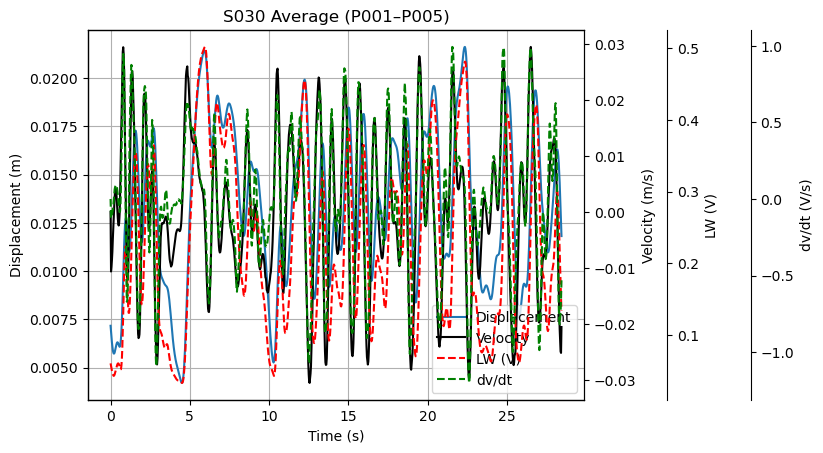

In [66]:
S_value = "030"

time, disp, vel, lw, dvdt = load_and_average(S_value, folder)
plot_results(time, disp, vel, lw, dvdt, S_value)

In [12]:
# for s in range(1, 29):
    
#     S_value = f"{s:03d}"
    
#     try:
#         time, disp, vel, lw, dvdt = load_and_average(S_value, folder)
        
#         # Call plotting function (now saves instead of shows)
#         plot_results(time, disp, vel, lw, dvdt, S_value)
        
#     except Exception as e:
#         print(f"Skipping S{S_value}: {e}")

42455
0.1651612903225806


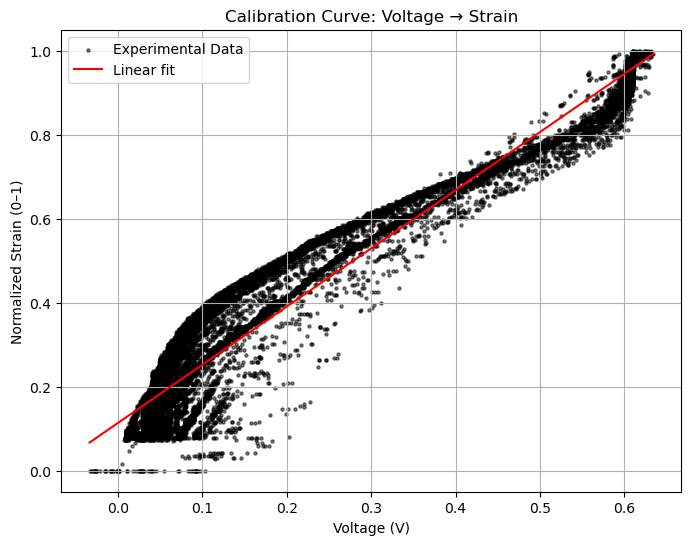

Linear fit:
strain = 1.385113 * V + 0.113759
R² linear: 0.9494256423865071


In [68]:
all_strain = []
all_lw = []

# --- Loop through all files ---
for s in range(1, 29):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            print(f"Missing: {filename}")
            continue
        
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        # --- Load columns ---
        strain = pd.to_numeric(df['strain'], errors='coerce')
        lw     = pd.to_numeric(df['LW (V)'], errors='coerce')
        
        # Drop NaNs
        valid = ~(strain.isna() | lw.isna())
        strain = strain[valid]
        lw = lw[valid]
        
        all_strain.append(strain.values)
        all_lw.append(lw.values)

# --- Concatenate all data ---
all_strain = np.concatenate(all_strain)
all_lw = np.concatenate(all_lw)
print(len(all_strain))

# --- Normalize strain (global max) ---
max_strain = np.max(all_strain)
print(max_strain)
strain_norm = all_strain / max_strain

# --- Fit: Voltage → Strain ---
# Linear fit: strain = a * V + b
coeffs_lin = np.polyfit(all_lw, strain_norm, 1)
fit_lin = np.poly1d(coeffs_lin)

# Polynomial fit (2nd order)
coeffs_poly = np.polyfit(all_lw, strain_norm, 2)
fit_poly = np.poly1d(coeffs_poly)

# --- Generate smooth curve ---
v_range = np.linspace(np.min(all_lw), np.max(all_lw), 500)

# --- Plot ---
plt.figure(figsize=(8,6))

# Scatter (light)
plt.scatter(all_lw[idx], strain_norm[idx], s=5, alpha=0.5, color = 'k', label = 'Experimental Data')

# Fits
plt.plot(v_range, fit_lin(v_range), label='Linear fit', color = 'r')
# plt.plot(v_range, fit_poly(v_range), linestyle='--', label='Quadratic fit', color = 'orange')

plt.xlabel("Voltage (V)")
plt.ylabel("Normalized Strain (0–1)")
plt.title("Calibration Curve: Voltage → Strain")
plt.legend()
plt.grid(True)

plt.show()

# --- Print equations ---
print("Linear fit:")
print(f"strain = {coeffs_lin[0]:.6f} * V + {coeffs_lin[1]:.6f}")

# print("\nQuadratic fit:")
# print(f"strain = {coeffs_poly[0]:.6f} * V^2 + {coeffs_poly[1]:.6f} * V + {coeffs_poly[2]:.6f}")

print("R² linear:", r2_score(strain_norm, fit_lin(all_lw)))
# print("R² quadratic:", r2_score(strain_norm, fit_poly(all_lw)))

### Strain from voltage and strain guage strain rate

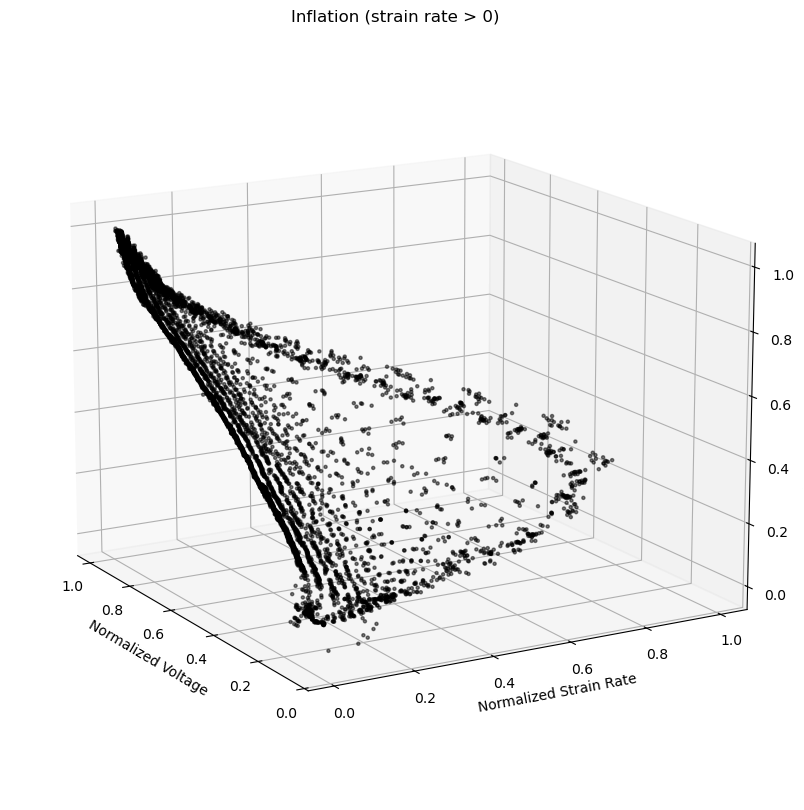

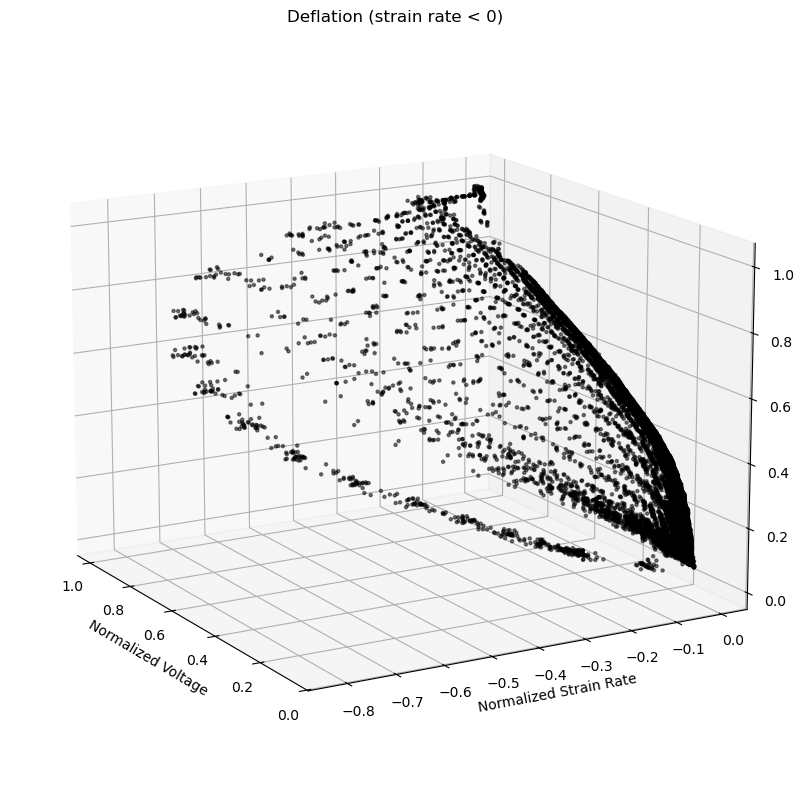

In [73]:
all_strain = []
all_strain_rate = []
all_voltage = []

# --- Load all data ---
for s in range(1, 29):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            continue
        
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        strain = pd.to_numeric(df['strain'], errors='coerce')
        strain_rate = pd.to_numeric(df['strain rate (1/s)'], errors='coerce')
        voltage = pd.to_numeric(df['LW (V)'], errors='coerce')
        
        valid = ~(strain.isna() | strain_rate.isna() | voltage.isna())
        
        all_strain.append(strain[valid].values)
        all_strain_rate.append(strain_rate[valid].values)
        all_voltage.append(voltage[valid].values)

# --- Combine ---
all_strain = np.concatenate(all_strain)
all_strain_rate = np.concatenate(all_strain_rate)
all_voltage = np.concatenate(all_voltage)

# --- Normalize ---
strain_norm = all_strain / np.max(all_strain)

# Normalize strain rate (preserve sign)
max_sr = np.max(np.abs(all_strain_rate))
strain_rate_norm = all_strain_rate / max_sr

# --- Normalize voltage ---
v_min = np.min(all_voltage)
v_max = np.max(all_voltage)

voltage_norm = (all_voltage - v_min) / (v_max - v_min)

# --- Split inflation / deflation ---
inflation_mask = strain_rate_norm > 0
deflation_mask = strain_rate_norm < 0

# =========================
# Inflation Plot
# =========================
fig1 = plt.figure(figsize = (10,10))
ax1 = fig1.add_subplot(111, projection='3d')

ax1.scatter(
    voltage_norm[inflation_mask],       # x (normalized voltage)
    strain_rate_norm[inflation_mask],   # y
    strain_norm[inflation_mask],        # z
    s=5,
    alpha=0.5,
    c='black'
)

ax1.set_xlabel("Normalized Voltage")
ax1.set_ylabel("Normalized Strain Rate")
ax1.set_zlabel("Normalized Strain")
ax1.set_title("Inflation (strain rate > 0)")

# Invert voltage axis
ax1.invert_xaxis()
ax1.view_init(elev=15, azim=-30) #

# =========================
# Deflation Plot
# =========================
fig2 = plt.figure(figsize = (10,10))
ax2 = fig2.add_subplot(111, projection='3d')

ax2.scatter(
    voltage_norm[deflation_mask],
    strain_rate_norm[deflation_mask],
    strain_norm[deflation_mask],
    s=5,
    alpha=0.5,
    c='black'
)

ax2.set_xlabel("Normalized Voltage")
ax2.set_ylabel("Normalized Strain Rate")
ax2.set_zlabel("Normalized Strain")
ax2.set_title("Deflation (strain rate < 0)")

# Invert voltage axis
ax2.invert_xaxis()
ax2.view_init(elev=15, azim=-30) #

plt.show()

### Strain from V and dV/dt

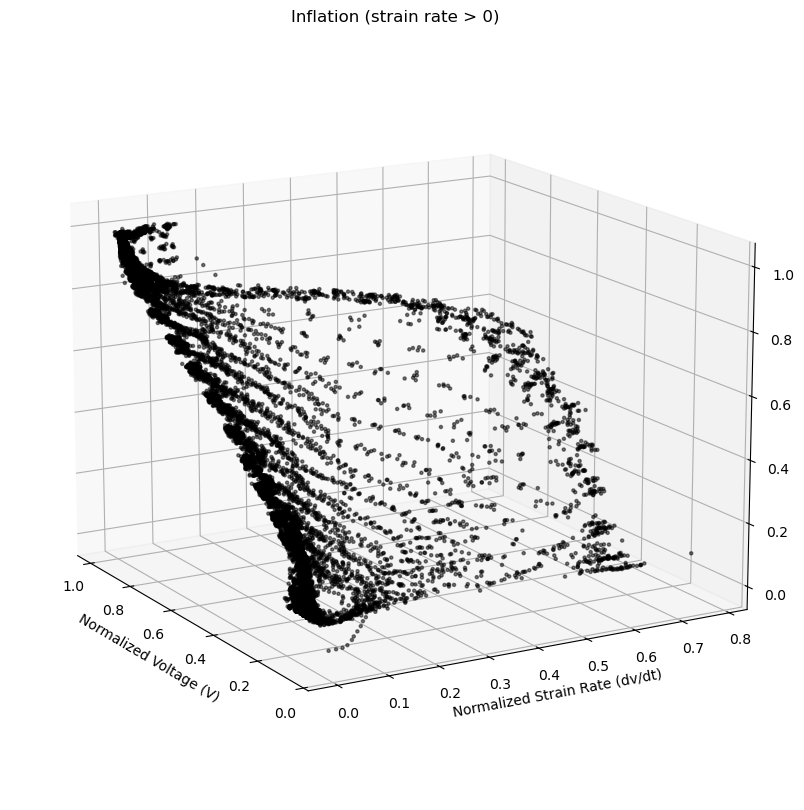

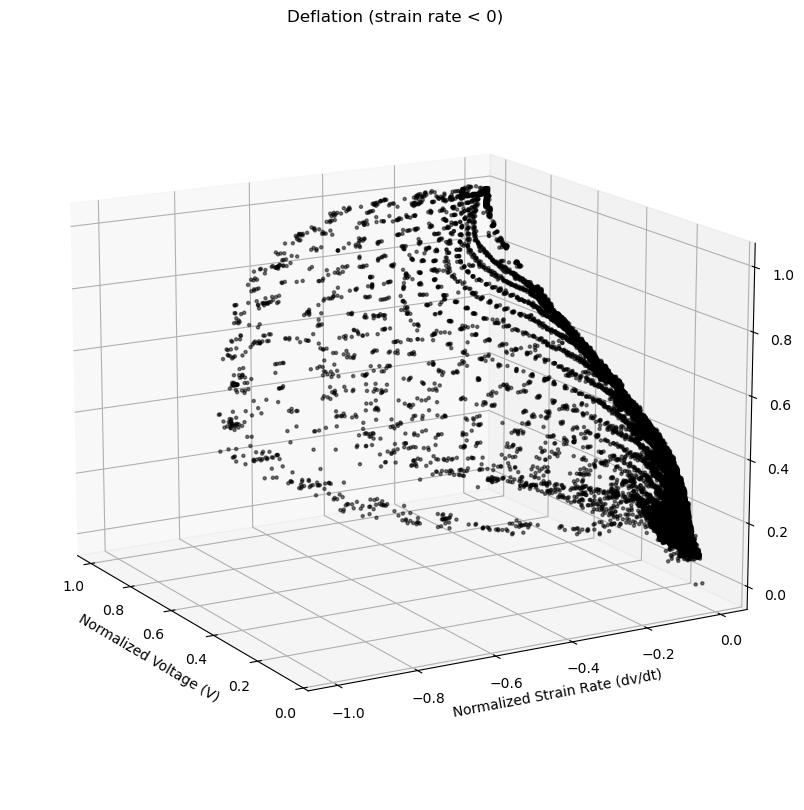

In [75]:
all_strain = []
all_dvdt = []
all_voltage = []

# --- Load all data ---
for s in range(1, 29):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            continue
        
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        strain = pd.to_numeric(df['strain'], errors='coerce')
        dvdt = pd.to_numeric(df['dv/dt'], errors='coerce')
        voltage = pd.to_numeric(df['LW (V)'], errors='coerce')
        
        valid = ~(strain.isna() | dvdt.isna() | voltage.isna())
        
        all_strain.append(strain[valid].values)
        all_dvdt.append(dvdt[valid].values)
        all_voltage.append(voltage[valid].values)

# --- Combine ---
all_strain = np.concatenate(all_strain)
all_dvdt = np.concatenate(all_dvdt)
all_voltage = np.concatenate(all_voltage)

# --- Normalize ---
strain_norm = all_strain / np.max(all_strain)

# Normalize strain rate (preserve sign)
max_sr = np.max(np.abs(all_dvdt))
dvdt_norm = all_dvdt / max_sr

# --- Normalize voltage ---
v_min = np.min(all_voltage)
v_max = np.max(all_voltage)

voltage_norm = (all_voltage - v_min) / (v_max - v_min)

# --- Split inflation / deflation ---
inflation_mask = dvdt_norm > 0
deflation_mask = dvdt_norm < 0

# =========================
# Inflation Plot
# =========================
fig1 = plt.figure(figsize = (10,10))
ax1 = fig1.add_subplot(111, projection='3d')

ax1.scatter(
    voltage_norm[inflation_mask],       # x (normalized voltage)
    dvdt_norm[inflation_mask],   # y
    strain_norm[inflation_mask],        # z
    s=5,
    alpha=0.5,
    c='black'
)

ax1.set_xlabel("Normalized Voltage (V)")
ax1.set_ylabel("Normalized Strain Rate (dv/dt)")
ax1.set_zlabel("Normalized Strain")
ax1.set_title("Inflation (strain rate > 0)")

# Invert voltage axis
ax1.invert_xaxis()
ax1.view_init(elev=15, azim=-30) #

# =========================
# Deflation Plot
# =========================
fig2 = plt.figure(figsize = (10,10))
ax2 = fig2.add_subplot(111, projection='3d')

ax2.scatter(
    voltage_norm[deflation_mask],
    dvdt_norm[deflation_mask],
    strain_norm[deflation_mask],
    s=5,
    alpha=0.5,
    c='black'
)

ax2.set_xlabel("Normalized Voltage (V)")
ax2.set_ylabel("Normalized Strain Rate (dv/dt)")
ax2.set_zlabel("Normalized Strain")
ax2.set_title("Deflation (strain rate < 0)")

# Invert voltage axis
ax2.invert_xaxis()
ax2.view_init(elev=15, azim=-30) #

plt.show()


Inflation Model (V, dV/dt):
strain = 1.1173*V^3 + -2.0501*V^2 + 1.9648*V + -0.2563*dVdt + 0.2308*(V*dVdt) + -0.0577*(V^2*dVdt) + 
R²   = 0.9800
RMSE = 0.044321

Deflation Model (V, dV/dt):
strain = 2.2798*V^3 + -4.0512*V^2 + 2.9153*V + 0.2728*dVdt + -0.3342*(V*dVdt) + -0.1248*(V^2*dVdt) + 
R²   = 0.9435
RMSE = 0.056502


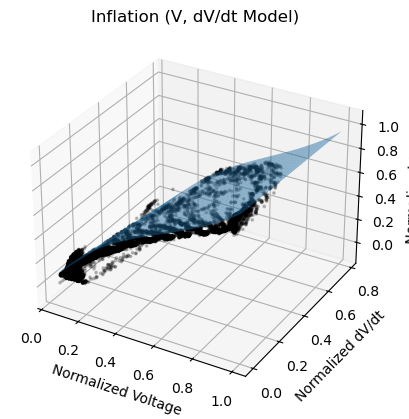

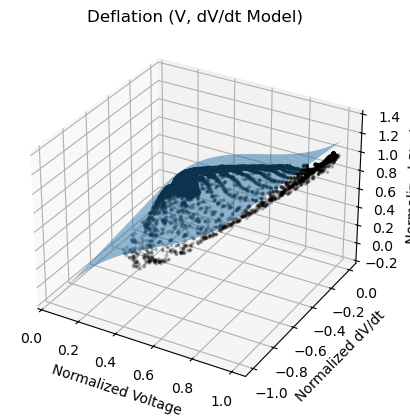

In [100]:
V = voltage_norm
dvdt = dvdt_norm
strain = strain_norm

inflation_mask = dvdt_norm > 0
deflation_mask = dvdt_norm < 0

def fit_voltage_model(V, dVdt, strain):
    """
    strain = a*V^3 + b*V^2 + c*V + d*dVdt + e*(V*dVdt) + f*(V^2*dVdt) + g
    """

    # --- Force numpy + flatten ---
    V = np.asarray(V).flatten()
    dVdt = np.asarray(dVdt).flatten()
    strain = np.asarray(strain).flatten()
    
    # --- Final safety check ---
    if not (len(V) == len(dVdt) == len(strain)):
        raise ValueError(f"Length mismatch: V={len(V)}, dVdt={len(dVdt)}, strain={len(strain)}")

    # --- Design matrix ---
    X = np.column_stack([
        V**3,
        V**2,
        V,
        dVdt,
        V * dVdt,
        V**2 * dVdt,
        np.ones_like(V)
    ])

    X = np.column_stack([
    V**3,
    V**2,
    V,
    dVdt,
    V*dVdt,
    np.ones_like(V)
])

    coeffs, _, _, _ = np.linalg.lstsq(X, strain, rcond=None)

    strain_pred = X @ coeffs

    r2 = r2_score(strain, strain_pred)
    rmse = np.sqrt(mean_squared_error(strain, strain_pred))

    return coeffs, strain_pred, r2, rmse

# Inflation
coeffs_inf_V, pred_inf_V, r2_inf_V, rmse_inf_V = fit_voltage_model(
    voltage_norm[inflation_mask],
    dvdt_norm[inflation_mask],
    strain_norm[inflation_mask]
)

# Deflation
coeffs_def_V, pred_def_V, r2_def_V, rmse_def_V = fit_voltage_model(
    voltage_norm[deflation_mask],
    dvdt_norm[deflation_mask],
    strain_norm[deflation_mask]
)

def print_voltage_model(name, coeffs, r2, rmse):
    print(f"\n{name} Model (V, dV/dt):")
    print("strain = "
          f"{coeffs[0]:.4f}*V^3 + "
          f"{coeffs[1]:.4f}*V^2 + "
          f"{coeffs[2]:.4f}*V + "
          f"{coeffs[3]:.4f}*dVdt + "
          f"{coeffs[4]:.4f}*(V*dVdt) + "
          f"{coeffs[5]:.4f}*(V^2*dVdt) + ")
          # f"{coeffs[6]:.4f}")
    
    print(f"R²   = {r2:.4f}")
    print(f"RMSE = {rmse:.6f}")

print_voltage_model("Inflation", coeffs_inf_V, r2_inf_V, rmse_inf_V)
print_voltage_model("Deflation", coeffs_def_V, r2_def_V, rmse_def_V)

def plot_voltage_surface(V, dVdt, strain, coeffs, title):
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(V, dVdt, strain, s=3, alpha=0.2, c='black')
    
    v_lin = np.linspace(np.min(V), np.max(V), 60)
    dv_lin = np.linspace(np.min(dVdt), np.max(dVdt), 60)
    Vg, DVg = np.meshgrid(v_lin, dv_lin)
    
    Zg = (
        coeffs[0]*Vg**3 +
        coeffs[1]*Vg**2 +
        coeffs[2]*Vg +
        coeffs[3]*DVg +
        coeffs[4]*(Vg*DVg) +
        coeffs[5]*(Vg**2 * DVg) #+
        # coeffs[6]
    )
    
    ax.plot_surface(Vg, DVg, Zg, alpha=0.5)
    
    ax.set_xlabel("Normalized Voltage")
    ax.set_ylabel("Normalized dV/dt")
    ax.set_zlabel("Normalized Strain")
    ax.set_title(title)
    
    plt.show()

plot_voltage_surface(
    voltage_norm[inflation_mask],
    dvdt_norm[inflation_mask],
    strain_norm[inflation_mask],
    coeffs_inf_V,
    "Inflation (V, dV/dt Model)"
)

plot_voltage_surface(
    voltage_norm[deflation_mask],
    dvdt_norm[deflation_mask],
    strain_norm[deflation_mask],
    coeffs_def_V,
    "Deflation (V, dV/dt Model)"
)


### Test the model


S029 Results:
R²   = -0.7116
RMSE = 0.112043


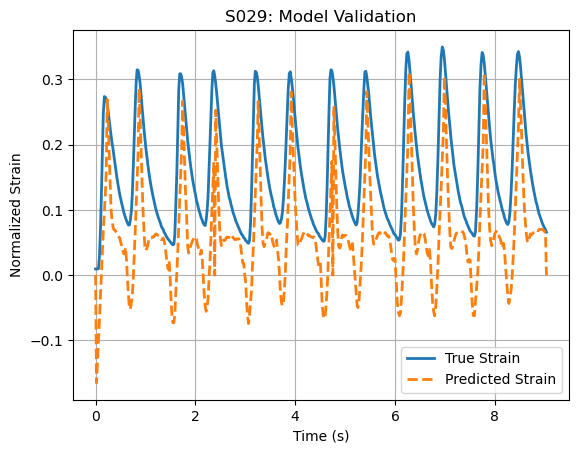

In [106]:
max_strain_training = np.max(all_strain)

def load_and_average_test(S_value, folder):
    
    V_list, dVdt_list, disp_list, time_list = [], [], [], []
    
    for p in range(1, 6):
        filename = f"S{S_value}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            continue
        
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        V = pd.to_numeric(df['LW (V)'], errors='coerce')
        dVdt = pd.to_numeric(df['dv/dt'], errors='coerce')
        disp = pd.to_numeric(df['Displacement (mm)'], errors='coerce')
        time = pd.to_numeric(df['t_rel(s)'], errors='coerce')
        
        valid = ~(V.isna() | dVdt.isna() | disp.isna() | time.isna())
        
        V_list.append(V[valid].values)
        dVdt_list.append(dVdt[valid].values)
        disp_list.append(disp[valid].values)
        time_list.append(time[valid].values)

    # --- Trim to shortest length ---
    min_len = min(len(v) for v in V_list)

    V_arr = np.array([v[:min_len] for v in V_list])
    dVdt_arr = np.array([v[:min_len] for v in dVdt_list])
    disp_arr = np.array([v[:min_len] for v in disp_list])
    time_arr = np.array([v[:min_len] for v in time_list])

    # --- Average ---
    V_mean = np.mean(V_arr, axis=0)
    dVdt_mean = np.mean(dVdt_arr, axis=0)
    disp_mean = np.mean(disp_arr, axis=0)
    time_mean = np.mean(time_arr, axis=0)

    return time_mean, V_mean, dVdt_mean, disp_mean

def predict_strain(V, dVdt, coeffs_inf, coeffs_def):
    
    strain_pred = np.zeros_like(V)
    
    threshold = 0.01
    
    infl_mask = dVdt > threshold
    defl_mask = dVdt < -threshold
    
    # Inflation
    if np.any(infl_mask):
        Vi = V[infl_mask]
        dVi = dVdt[infl_mask]
        
        strain_pred[infl_mask] = (
            coeffs_inf[0]*Vi**3 +
            coeffs_inf[1]*Vi**2 +
            coeffs_inf[2]*Vi +
            coeffs_inf[3]*dVi +
            coeffs_inf[4]*(Vi*dVi) +
            coeffs_inf[5]*(Vi**2 * dVi) #+
            # coeffs_inf[6]
        )
    
    # Deflation
    if np.any(defl_mask):
        Vd = V[defl_mask]
        dVd = dVdt[defl_mask]
        
        strain_pred[defl_mask] = (
            coeffs_def[0]*Vd**3 +
            coeffs_def[1]*Vd**2 +
            coeffs_def[2]*Vd +
            coeffs_def[3]*dVd +
            coeffs_def[4]*(Vd*dVd) +
            coeffs_def[5]*(Vd**2 * dVd) #+
            # coeffs_def[6]
        )
    
    return strain_pred

def compute_normalized_strain(disp_mm, L0, max_strain_training):
    
    strain = disp_mm / (1000 * L0)
    strain_norm = strain / max_strain_training
    
    return strain_norm

L0 = 0.155

for S_value in ["029"]:
    
    time, V, dVdt, disp = load_and_average_test(S_value, folder)
    
    # --- Normalize inputs (IMPORTANT: same scaling as training) ---
    V_norm = (V - np.min(voltage_norm)) / (np.max(voltage_norm) - np.min(voltage_norm))
    dVdt_norm_test = dVdt / np.max(np.abs(dvdt_norm))  # use training scale
    
    # --- True strain ---
    strain_true = compute_normalized_strain(disp, L0, max_strain_training)
    
    # --- Predict ---
    strain_pred = predict_strain(
        V_norm,
        dVdt_norm_test,
        coeffs_inf_V,
        coeffs_def_V
    )
    
    # --- Metrics ---
    r2 = r2_score(strain_true, strain_pred)
    rmse = np.sqrt(mean_squared_error(strain_true, strain_pred))
    
    print(f"\nS{S_value} Results:")
    print(f"R²   = {r2:.4f}")
    print(f"RMSE = {rmse:.6f}")
    
    # --- Plot ---
    plt.figure()
    plt.plot(time, strain_true, label="True Strain", linewidth=2)
    plt.plot(time, strain_pred, '--', label="Predicted Strain", linewidth=2)
    
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Strain")
    plt.title(f"S{S_value}: Model Validation")
    plt.legend()
    plt.grid()
    
    plt.show()

In [96]:
print("Training max strain:", max_strain_training)
print("Test max strain:", np.max(disp / (1000 * L0)))

Training max strain: 0.1651612903225806
Test max strain: 0.05775483870967743


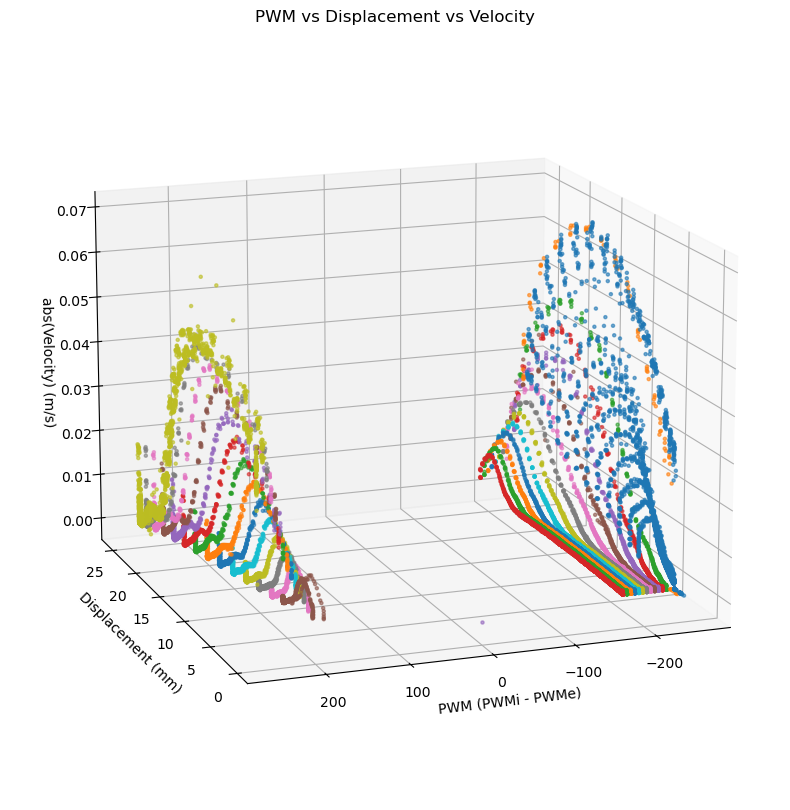

In [28]:
all_disp = []
all_vel = []
all_pwm = []

# --- Load all data ---
for s in range(1, 29):
    for p in range(1, 6):
        
        filename = f"S{s:03d}P{p:03d}.csv"
        file_path = os.path.join(folder, filename)
        
        if not os.path.exists(file_path):
            continue
        
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        
        disp = pd.to_numeric(df['Displacement (mm)'], errors='coerce')
        vel = pd.to_numeric(df['vel (m/s)'], errors='coerce')
        
        pwmi = pd.to_numeric(df['PWMi'], errors='coerce')
        pwme = pd.to_numeric(df['PWMe'], errors='coerce')
        pwm = pwmi - pwme
        
        valid = ~(disp.isna() | vel.isna() | pwm.isna())
        
        all_disp.append(disp[valid].values)
        all_vel.append(vel[valid].values)
        all_pwm.append(pwm[valid].values)

# --- Combine ---
all_disp = np.concatenate(all_disp)
all_vel = np.concatenate(all_vel)
all_pwm = np.concatenate(all_pwm)

# --- Unique PWM values for consistent coloring ---
unique_pwm = np.unique(all_pwm)

cmap = plt.get_cmap('tab10')
colors = {pwm: cmap(i % 10) for i, pwm in enumerate(unique_pwm)}

# --- Plot ---
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

for pwm_val in unique_pwm:
    mask = all_pwm == pwm_val
    
    ax.scatter(
        all_pwm[mask],   # X (PWM) 
        all_disp[mask],  # Y (Displacement)
        abs(all_vel[mask]),   # Z (Velocity)
        s=5,
        alpha=0.6,
        color=colors[pwm_val],
        label=f"PWM {int(pwm_val)}"
    )

ax.set_xlabel("PWM (PWMi - PWMe)")
ax.set_ylabel("Displacement (mm)")
ax.set_zlabel("abs(Velocity) (m/s)")
ax.set_title("PWM vs Displacement vs Velocity")
ax.view_init(elev=15, azim=-110) #
ax.invert_xaxis()


# ax.legend(loc='upper right', markerscale=3)

plt.show()